In [1]:
# Импортируем необходимые библиотеки

import pandas as pd
from operator import attrgetter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as st
from statsmodels.stats.multitest import multipletests

- Проведем EDA (Exploratory Data Analysis) - разведочный анализ данных

In [2]:
# Считываем датасеты
# В order_data и order_items_data сразу переводим даты в тип datetime

customer_data = pd.read_csv('olist_customers_dataset.csv')
order_data = pd.read_csv('olist_orders_dataset.csv', 
                         parse_dates=['order_purchase_timestamp',
                                      'order_approved_at', 
                                      'order_delivered_carrier_date',
                                      'order_delivered_customer_date', 
                                      'order_estimated_delivery_date'])
order_items_data = pd.read_csv('olist_order_items_dataset.csv',
                               parse_dates=['shipping_limit_date'])

In [4]:
# Проведем первичный осмотр данных (первые строки, типы данных, размер)

customer_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
customer_data.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [7]:
customer_data.shape

(99441, 5)

In [8]:
order_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [9]:
order_data.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [11]:
order_data.shape

(99441, 8)

In [12]:
order_items_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
order_items_data.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

In [15]:
order_items_data.shape

(112650, 7)

Типы данных корректные и соответствуют содержимому, названия колонок понятные, не содержат пробелов для удобства работы с ними.

In [6]:
# Проверим наличие NaN значений и дубликатов в датасетах

customer_data.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [84]:
customer_data.duplicated().sum()

0

In [10]:
order_data.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [85]:
order_data.duplicated().sum()

0

In [14]:
order_items_data.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [86]:
order_items_data.duplicated().sum()

0

Полностью повторяющихся строк в датасетах не обнаружено.

Есть пропуски в order_data, которые требуют дополнительной проверки.

Также проверим данные на логическую целостность и аномалии.

In [114]:
# Убедимся, что колонки customer_id и customer_unique_id имеют разный характер:
# customer_id - для обозначения сессии, customer_unique_id - реальный id

id_columns = customer_data[['customer_id', 'customer_unique_id']]
unique_ids = id_columns.nunique()

session_count = (
    id_columns
    .groupby('customer_unique_id', as_index=False)
    .agg({'customer_id':'nunique'})
    .value_counts('customer_id')
)
print(f'{unique_ids.customer_id} уникальных сессий, соответствует количеству строк в датасете\n'
      f'{unique_ids.customer_unique_id} уникальных id\n\n'
      f'Частота сессий на пользователя:\n{session_count}')

99441 уникальных сессий, соответствует количеству строк в датасете
96096 уникальных id

Частота сессий на пользователя:
 customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
dtype: int64


In [154]:
# Проверим, что номер заказа уникален в таблице с заказами
duplicates_order_id = order_data.order_id.duplicated().sum()
duplicates_order_id

0

In [138]:
# Проверим логическую согласованность временных колонок:
# нет ли заказов, где дата доставки/подтверждения < времени создания
anomaly_orders_timestamp = (
    order_data
    .query("""
    order_purchase_timestamp > order_approved_at or \
    order_purchase_timestamp > order_delivered_customer_date
    """)
    .shape
)

# то же самое только для времени передачи в доставку 
anomaly_orders_timestamp2 = (
    order_data
    .query('order_purchase_timestamp > order_delivered_carrier_date')
    .shape
)

# время доставки раньше времени передачи курьеру
anomaly_orders_timestamp3 = (
    order_data
    .query('order_delivered_customer_date < order_delivered_carrier_date')
    .shape
)

print(f'Количество заказов, где время оформления позже,\n'
      f'чем время подтверждения оплаты или доставки:{anomaly_orders_timestamp[0]}\n\n'
      f'Количество заказов, где время оформления позже,\n'
      f'чем время передачи курьеру:{anomaly_orders_timestamp2[0]}\n\n'
      f'Количество заказов, где время доставки раньше,\n'
      f'чем время передачи курьеру:{anomaly_orders_timestamp3[0]}')

Количество заказов, где время оформления позже,
чем время подтверждения оплаты или доставки:0

Количество заказов, где время оформления позже,
чем время передачи курьеру:166

Количество заказов, где время доставки раньше,
чем время передачи курьеру:23


In [16]:
# Проверим, какие статусы у неподтвержденных заказов (NaN в order_approved_at)

not_approved = (order_data[order_data.order_approved_at.isna()]
                .order_status
                .value_counts())
print(f'{not_approved}\n')
print(f'Техническая аномалия: {not_approved.delivered} заказов успешно доставлены клиентам,\n'
      f'но не имеют зафиксированного времени подтверждения оплаты')

canceled     141
delivered     14
created        5
Name: order_status, dtype: int64

Техническая аномалия: 14 заказов успешно доставлены клиентам,
но не имеют зафиксированного времени подтверждения оплаты


In [172]:
# Проверим, есть ли доставленные заказы, у которых нет даты доставки
delivered_no_date = (
    order_data[order_data.order_status == 'delivered']
    .order_delivered_customer_date
    .isna()
    .sum()
)

# Проверим, есть ли заказы с датой доставки, но у которых статус не 'delivered'
not_delivered_but_date =(
    order_data[order_data.order_delivered_customer_date.notna()]
    .query('order_status != "delivered"')
    .shape
)

print(f'Доставленных заказов без даты доставки: {delivered_no_date}\n'
      f'Заказы с датой доставки, но статус canceled: {not_delivered_but_date[0]}')

Доставленных заказов без даты доставки: 8
Заказы с датой доставки, но статус canceled: 6


Для дальнейшего анализа retention нужно определить, что делать с заказами, у которых есть дата доставки, но статус не delivered.

Т.к. могла быть поздняя отмена или возврат товара после получения, я буду опираться на статус, как на приоритетный маркер для последующей фильтрации данных.

In [160]:
# Проверим, что в датасете с товарами нет отрицательных или нулевых цен
# или отрицательной стоимости доставки
order_items_data.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [169]:
# Проверим, что все заказы из таблицы с товарами есть в таблице с заказами
set1 = set(order_items_data.order_id)
set2 = set(order_data.order_id)

diff_sets = set1.difference(set2)
diff_sets

set()

### Задача 1.  Оценить месячный retention в оформление заказа с помощью когортного анализа

1. Избавляемся от заказов со статусом 'canceled' и 'unavailable', чтобы оставить только интересующие нас заказы (в процессе и доставленные).
2. Добавляем информацию об уникальном id пользователя из таблицы customer_data.
3. Создаем копию датасета, чтобы избежать изменений в исходном.

In [18]:
filtered_orders = order_data[~order_data.order_status \
    .isin(['unavailable', 'canceled'])] \
    .merge(customer_data[['customer_id', 'customer_unique_id']], 
           how='left', on='customer_id') \
    .copy()

4. Извлекаем день для каждого заказа из отфильтрованного датасета для дальнейшего расчета номера периода заказов.

In [19]:
filtered_orders['order_period_day'] = filtered_orders.order_purchase_timestamp \
    .dt.to_period('D')

5. Присваиваем когорту каждому пользователю на основе первого оформленного заказа.
6. Рассчитываем номер месячного периода для каждого заказа.

In [20]:
filtered_orders['cohort'] = filtered_orders.groupby('customer_unique_id') \
    .order_purchase_timestamp \
    .transform('min').dt.to_period('M')

filtered_orders['cohort_day'] = filtered_orders.groupby('customer_unique_id') \
    .order_purchase_timestamp \
    .transform('min').dt.to_period('D')

filtered_orders['period_month'] = np.floor((filtered_orders.order_period_day - filtered_orders.cohort_day) \
    .apply(attrgetter('n')) / 30)

7. Агрегируем данные по когортам и месячному периоду и считаем количество уникальных клиентов в каждой группировке.

In [21]:
cohort_data = filtered_orders.groupby(['cohort', 'period_month']) \
    .agg(number_of_customers=('customer_unique_id', 'nunique')).reset_index()

8. Pivot-им таблицу и создаем переменную с размерами когорт.

In [22]:
cohort_pivot_data = cohort_data \
    .pivot(index='cohort', columns='period_month', values='number_of_customers')

cohort_size = cohort_pivot_data.iloc[:, 0]

9. Считаем месячный retention в долях.

In [23]:
retention_matrix = cohort_pivot_data.divide(cohort_size, axis=0)

retention_matrix.head()

period_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003448,NaN,NaN,0.003448,...,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,0.006897,0.003448,0.003448
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002660,NaN,0.005319,0.001330,0.001330,0.002660,0.002660,NaN,NaN,...,0.005319,0.003989,0.002660,NaN,0.002660,0.002660,0.002660,0.001330,NaN,NaN
2017-02,1.0,0.001775,0.001775,0.003550,0.002367,0.001183,0.002367,0.000592,0.001183,0.002367,...,0.003550,0.000592,0.001775,0.001183,0.000592,0.001183,0.002367,NaN,NaN,NaN


10. Считаем, чему равен медианный retention 1-го месяца в долях.

In [24]:
first_month_retention_median = retention_matrix.iloc[:,1].median()
print(first_month_retention_median.round(4))

0.0037


11. Найдем когорту с самым высоким retention на 3-ий месяц.

In [25]:
highest_retention_cohort = retention_matrix.iloc[:,3].idxmax()
print(highest_retention_cohort)

2017-01


12. Построим тепловую карту для визуализации без учета 0-ой когорты.
- Создаем датафрейм cohort_size_data для отображения размеров когорт на графике.



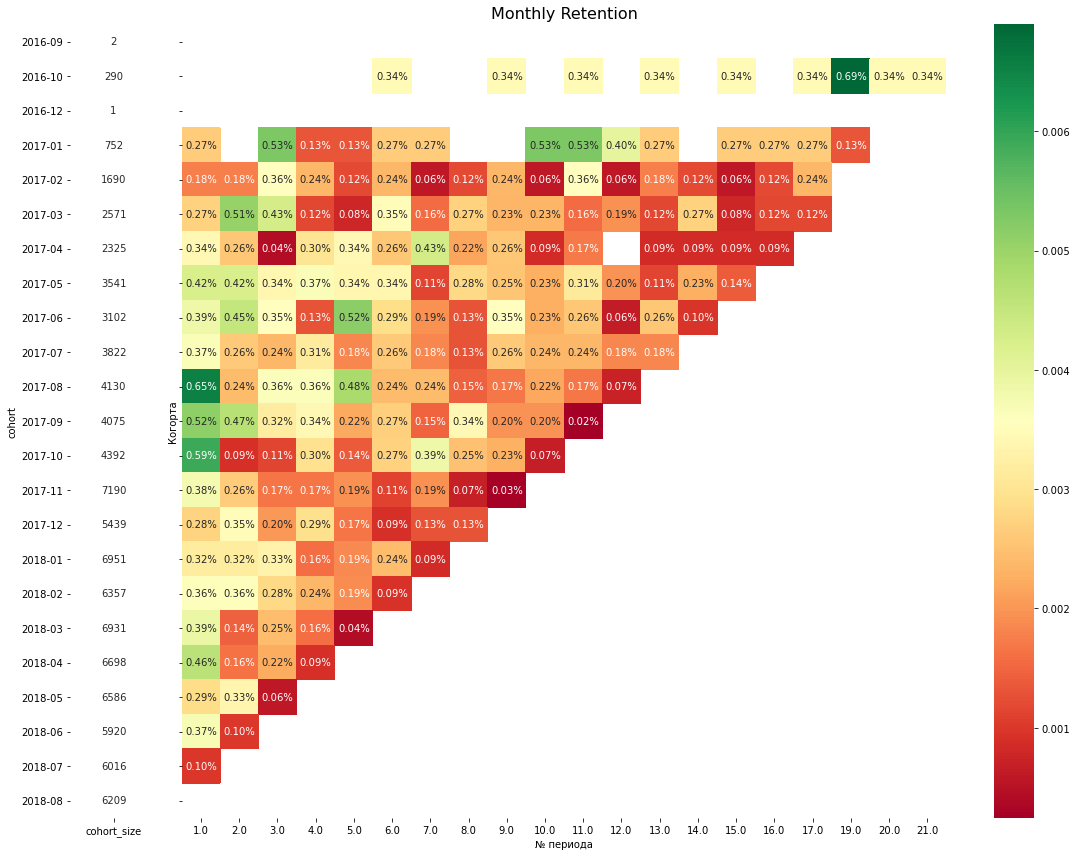

In [26]:
heatmap_data = retention_matrix.iloc[:, 1:]
cohort_size_data = cohort_size.to_frame().rename(columns={0.0: 'cohort_size'})

fig, ax = plt.subplots(1, 2, figsize=(16, 12), 
                       sharey=True, 
                       gridspec_kw={'width_ratios': [1, 11]})

sns.heatmap(heatmap_data, 
            annot=True,
            fmt='.2%', 
            cmap='RdYlGn',
            ax=ax[1])
ax[1].set_title('Monthly Retention', fontsize=16)
ax[1].set(xlabel='№ периода', ylabel='Когорта')

white_color = mcolors.ListedColormap(['white'])
sns.heatmap(cohort_size_data,
            annot=True,
            cbar=False,
            fmt='g',
            cmap=white_color,
            ax=ax[0])

plt.tight_layout()

### Вывод по задаче 1: 
1. Значения retention менее 1% - критически низкий. 
2. Активное привлечение клиентов началось c января 2017 года, когорты до этого выглядят как тестовые.
3. На каждые 10000 клиентов, совершивших первый заказ, только около 37 человек возвращаются за повторным заказом в течение следующих 30 дней.
4. Когорта январь 2017 имеет максимальное удержание на 3-ий месяц.

---

### Задача 2.  Определить, существует ли product/market fit у маркетплейса

За силу PMF отвечает метрика retention. По итогам когортного анализа уже видно, что значения retention крайне низкие и не выходят за пределы 0.65%.
1. Построим график медианного retention по периодам и убедимся, что удержание стремится к нулю.

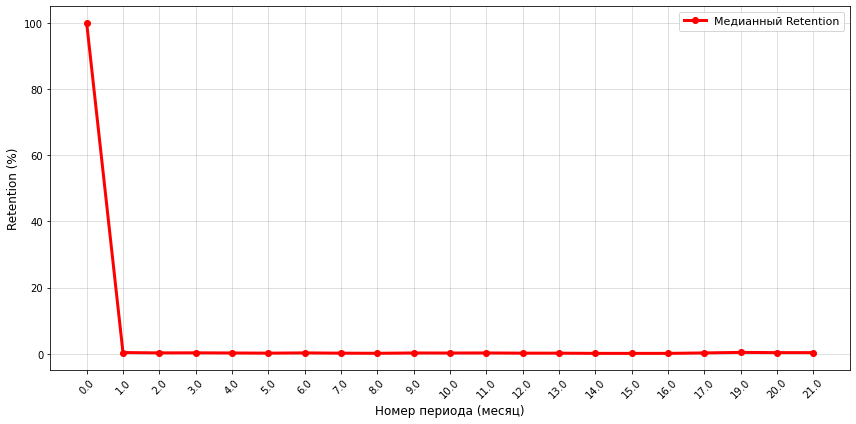

In [27]:
median_retention_all = retention_matrix.mul(100).median(axis=0)

plt.figure(figsize=(12, 6))

plt.plot(range(len(median_retention_all)), 
         median_retention_all, 
         marker='o', 
         color='red', 
         linewidth=3, 
         label='Медианный Retention')

plt.xticks(ticks=range(len(median_retention_all)), 
           labels=median_retention_all.index, 
           rotation=45)

plt.xlabel('Номер периода (месяц)', fontsize=12)
plt.ylabel('Retention (%)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

2. Проверим несколько гипотез низкого retention.

**2.1. Гипотеза 1: Клиенты не возвращаются повторно в продукт (низкий retention), т.к. маркетплейс доставляет заказы долго и с задержкой.**

- Подготовим датасет для анализа: выберем только доставленные заказы, добавим уникальный id клиента.

In [28]:
delivered_orders = order_data[order_data.order_status == 'delivered'] \
    .merge(customer_data[['customer_id', 'customer_unique_id']], 
           how='left', on='customer_id') \
    .copy()

- Посмотрим на распределение времени доставки с момента оформления заказа.

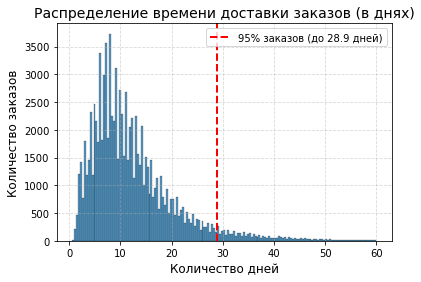

In [29]:
# Вычисляем количество дней на доставку
delivery_time = delivered_orders.order_delivered_customer_date - delivered_orders.order_purchase_timestamp
delivery_days = delivery_time.dt.total_seconds() / 86400

# Очищаем данные от пропусков и срежем выбросы
clean_data = delivery_days.dropna()
clean_data = clean_data[clean_data < 60] 

# Построим распределение и посмотрим на 95 процентиль
limit_95 = clean_data.quantile(0.95)

sns.histplot(clean_data)
plt.axvline(limit_95, color='red', linestyle='--', linewidth=2, 
            label=f'95% заказов (до {limit_95:.1f} дней)')
plt.legend()
plt.title('Распределение времени доставки заказов (в днях)', fontsize=14)
plt.xlabel('Количество дней', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

- Посмотрим на медианное время доставки.

In [30]:
median_delivery_time = delivery_days.median()
print(f'Медианное время доставки: {median_delivery_time.round(2)} дней')

Медианное время доставки: 10.22 дней


- Проверим, какая доля заказов доставляется вовремя/с задержкой.

In [31]:
# Считаем разницу в днях между ожидаемым временем доставки и фактом,
# уберем NaN значения из колонок расчета
delivered_orders['diff_in_delivery_days'] = (delivered_orders.order_delivered_customer_date - delivered_orders.order_estimated_delivery_date) \
    .dt.total_seconds() / 86400

delivered_orders = delivered_orders[delivered_orders['diff_in_delivery_days'].notna()]

# Присваиваем статус в зависимости от значения разницы
delivered_orders['is_delayed'] = delivered_orders.diff_in_delivery_days \
   .apply(lambda x: 'on_time' if x <=0 else 'delayed') 

# Посмотрим на доли заказов, доставленных вовремя и с задержкой
delivered_orders.is_delayed.value_counts(normalize=True)

on_time    0.918876
delayed    0.081124
Name: is_delayed, dtype: float64

- Сравним вовзращаемость клиентов за повторным заказом.

In [32]:
# Выберем клиентов, у которых больше 1 заказа
repeated_customers = delivered_orders.groupby('customer_unique_id', as_index=False) \
    .agg({'order_id': 'nunique'}).query('order_id > 1')

# Проставим статус клиента на основе повторного заказа
delivered_orders['is_repeated'] = delivered_orders.customer_unique_id \
    .isin(repeated_customers.customer_unique_id)

# Посчитаем процент возвращаемости относительно своевременности доставки
delivered_orders.groupby('is_delayed').is_repeated.mean().mul(100)

is_delayed
delayed    5.277281
on_time    6.213619
Name: is_repeated, dtype: float64

- Выясним, есть ли стат значимая разница между возвращаемостью в 2-х группах.

In [33]:
# Создадим таблицу сопряженности 2х категориальных переменных
contingency_table_1 = pd.crosstab(delivered_orders.is_delayed, delivered_orders.is_repeated)

# Используем критерий Хи-квадрат для проверки нулевой гипотезы 
# об отсутствии различий в распределении 2-х категориальных переменных

st.chi2_contingency(contingency_table_1)

Chi2ContingencyResult(statistic=10.78186115622945, pvalue=0.0010249956805795013, dof=1, expected_freq=array([[ 7345.66677724,   480.33322276],
       [83203.33322276,  5440.66677724]]))

**Выводы гипотеза 1:**

Что говорят данные:
1. 95% заказов доставляются в период до 29 дней.
2. Медианное время доставки: 10.22 дня.
3. Почти 92% заказов доставляется вовремя, доля заказов с опозданием меньше 8%.

Выводы:
1. 10.22 дня на доставку для маркетплейса достаточно на современном рынке, учитывая что маркетплейс доставляет в города по стране. 
2. Возвращаемость клиентов, которым задержали доставку, значимо ниже. Однако 92% заказов доставлены вовремя, но все равно имеют возвращемость 6.21%, что критически мало, это означает, что ключевая проблема не во времени доставки.

**2.2. Гипотеза 2: Клиенты не возвращаются повторно в продукт, из-за высокой стоимости доставки.**

- Посчитаем долю стоимости доставки в заказе.

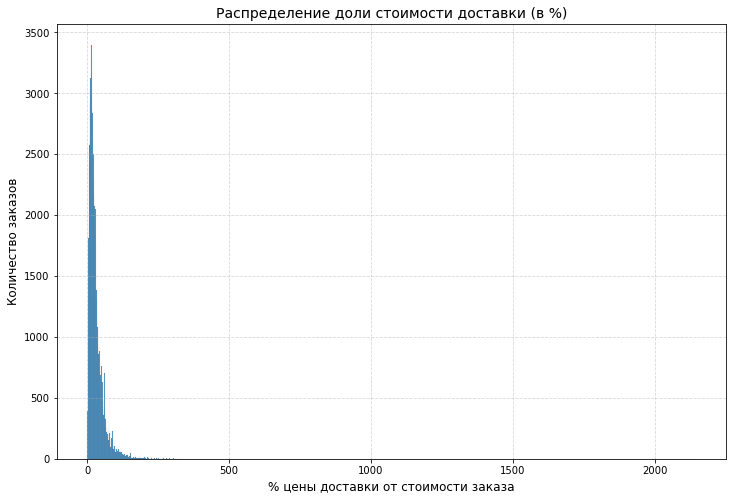

In [34]:
# Добавим инфо о статусах заказов, уберем неуспешные.
# Посчитаем сумму каждого заказа и стоимость доставки

total_order_price = order_items_data \
    .merge(order_data[['order_status', 'order_id']], how='left', on='order_id') \
    .query('order_status not in ["canceled", "unavailable"]') \
    .groupby('order_id', as_index=False) \
    .agg({'price': 'sum', 'freight_value': 'sum'})

# Посчитаем, какой процент занимает стоимость доставки в заказе
total_order_price['freight_proportion'] = (total_order_price.freight_value / total_order_price.price).mul(100)

# Посмотрим на распределение переменной (% стоимости доставки от заказа)
plt.figure(figsize=(12,8))

sns.histplot(data=total_order_price.freight_proportion)

plt.title('Распределение доли стоимости доставки (в %)', fontsize=14)
plt.xlabel('% цены доставки от стоимости заказа', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

- Посчитаем медиану % доставки, т.к. видим экстремальные выбросы в распределении.



In [35]:
median_freight_proportion = total_order_price.freight_proportion.median()
print(median_freight_proportion.round(2))

22.44


- Проверим, есть ли взаимосвязь между регионом доставки и стоимостью доставки.

In [36]:
# Подготовим датасет
customer_order_data = order_data[['order_id', 'customer_id', 'order_status']] \
    .merge(customer_data, how='left', on='customer_id') \
    .merge(total_order_price, how='left', on='order_id') \
    .query('order_status not in ["canceled", "unavailable"]') \
    .dropna()

# Сравним медианы % доставки от суммы заказа для каждого штата
state_prices = customer_order_data.groupby('customer_state', as_index=False) \
    .agg({'freight_proportion': 'median', 'order_id': 'nunique'}) \
    .sort_values('freight_proportion', ascending=False) \
    .rename(columns={'freight_proportion':'median_freight_proportion', 
                     'order_id': 'order_amount'})

In [37]:
# Создадим копию датасета
customer_order_data_copy = customer_order_data.copy()

# Посчитаем медиану % доставки от стоимости заказа
median_freight_proportion = customer_order_data_copy.freight_proportion.median()

# Добавим статус в зависимости от % доставки
customer_order_data_copy['freight_status'] = customer_order_data_copy.freight_proportion \
    .apply(lambda x: 'low' if x<= median_freight_proportion else 'high')

In [38]:
# Добавим в датасет информацию о возвращаемости клиентов
repeated_freight_status = customer_order_data_copy \
    .merge(delivered_orders[['customer_unique_id', 'is_repeated', 'order_id']], 
          how='left', on=['customer_unique_id', 'order_id'])

In [39]:
# Посчитаем процент возвращаемости относительно % доставки в заказе
repeated_freight_status.groupby('freight_status').is_repeated \
    .mean().mul(100)

freight_status
high    6.396482
low     5.879062
Name: is_repeated, dtype: float64

In [40]:
# Подготовим таблицу сопряженности 2-х категориальных переменных:
# возвращаемость и дороговизна доставки (по статусам)
contingency_table_2 = pd.crosstab(repeated_freight_status.freight_status, repeated_freight_status.is_repeated)

# Используем критерий Хи-квадрат для сравнения распределений
st.chi2_contingency(contingency_table_2)

Chi2ContingencyResult(statistic=11.118299804413125, pvalue=0.0008548010821132823, dof=1, expected_freq=array([[45254.78890847,  2959.21109153],
       [45294.21109153,  2961.78890847]]))

- Проведем когортный анализ для региона с самым большим количеством заказов и самой низкой медианной долей доставки.

In [41]:
filtered_orders_SP = filtered_orders \
    .merge(customer_data[['customer_unique_id', 'customer_state']], 
           how='left', on='customer_unique_id') \
    .query('customer_state == "SP"')

cohort_data_SP = filtered_orders_SP.groupby(['cohort', 'period_month']) \
    .agg(number_of_customers=('customer_unique_id', 'nunique')).reset_index()

cohort_pivot_data_SP = cohort_data_SP \
    .pivot(index='cohort', columns='period_month', values='number_of_customers')

cohort_size_SP = cohort_pivot_data_SP.iloc[:, 0]

retention_matrix_SP = cohort_pivot_data_SP.divide(cohort_size_SP, axis=0)

- Построим тепловую карту по когортам региона SP.

**2.2. Гипотеза 2: Клиенты не возвращаются повторно в продукт, из-за высокой стоимости доставки.**

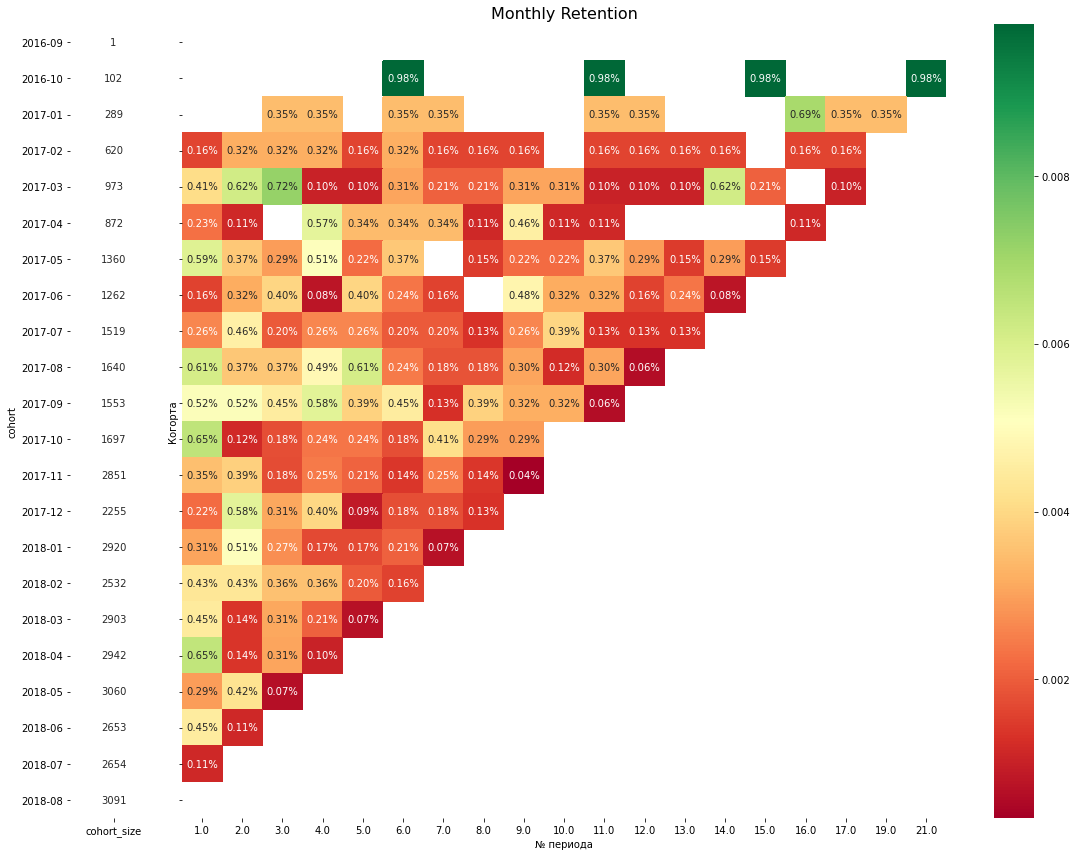

In [42]:
heatmap_data_SP = retention_matrix_SP.iloc[:, 1:]
cohort_size_data_SP = cohort_size_SP.to_frame().rename(columns={0.0: 'cohort_size'})

fig, ax = plt.subplots(1, 2, figsize=(16, 12), 
                       sharey=True, 
                       gridspec_kw={'width_ratios': [1, 11]})

sns.heatmap(heatmap_data_SP, 
            annot=True,
            fmt='.2%', 
            cmap='RdYlGn',
            ax=ax[1])
ax[1].set_title('Monthly Retention', fontsize=16)
ax[1].set(xlabel='№ периода', ylabel='Когорта')

white_color = mcolors.ListedColormap(['white'])
sns.heatmap(cohort_size_data_SP,
            annot=True,
            cbar=False,
            fmt='g',
            cmap=white_color,
            ax=ax[0])

plt.tight_layout()

**Выводы гипотеза 2:**

Что говорят данные:
1. 22.44% - медианный % стоимости доставки в заказе.
2. Топ-10 самых высоких медиан по % доставки в заказе от почти 48% до 33%.
3. В регионе SP также низкий ретеншн, менее 1%.
4. Есть статистически значимая разница в удержании клиентов относительно того, сколько % занимает стоимость доставки в стоимости заказа.

Выводы:
1. Стоимость доставки в почти четверть от заказа является серьезным фактором, который может снижать желание возвращаться к повторным покупкам. Практически эта разница для бизнеса слишком мала, чтобы объяснить низкий PMF. Более того, группа с более дорогой доставкой относительно стоимости заказа возвращается в повторную покупку стат значимо чаще, это может быть связано с отсутствием альтернатив в удаленных регионах.
2. Даже в штате SP, где условия доставки наилучшие, удержание менее 1%. Это говорит о том, что локального PMF у продукта тоже нет.

**2.3. Гипотеза 3: Клиенты не возвращаются повторно в продукт, из-за отмен и недоступности товаров на складах.**

- Посчитаем, какой процент неудачных заказов от всех заказов.

In [43]:
canceled_unavailaible_orders_proportion = order_data.order_status \
    .isin(['canceled', 'unavailable']) \
    .mean() * 100
print(round(canceled_unavailaible_orders_proportion,2))

1.24


- Подготовим данные для статистического теста, чтобы сравнить разницу в возвращаемости клиентов относительно успешности их первого заказа.

In [44]:
# Добавим инфо об уникальном id клиента
order_data_unique_id = order_data \
    .merge(customer_data[['customer_id', 'customer_unique_id']], 
           how='left', on='customer_id')

# Найдем первый заказ для каждого клиента
first_order = order_data_unique_id \
    .groupby('customer_unique_id', as_index=False) \
    .agg({'order_purchase_timestamp': 'min'})

# Соединим 2 датасета
first_order_status = first_order \
    .merge(order_data_unique_id[['order_status', 'order_purchase_timestamp', 'customer_unique_id']], 
           how='left', 
           on=['customer_unique_id', 'order_purchase_timestamp'])

# Оставим только успешные заказы и неудачные
first_order_status_filtered = first_order_status \
    .loc[first_order_status.order_status.isin(['delivered', 'canceled', 'unavailable'])] \
    .copy()

# На основании статуса заказа присвоим успешность, деля тем самым на 2 группы 
first_order_status_filtered['is_successful'] = first_order_status_filtered.order_status \
    .apply(lambda x: 'successful' if x == "delivered" else 'unsuccessful')

In [45]:
# Укажем, является ли заказ первым или повторным
repeated_customer_status = order_data_unique_id.groupby('customer_unique_id', as_index=False) \
    .agg({'order_id': 'nunique'}) \
    .assign(is_repeated= lambda x: x.order_id > 1)

# Объединим датасеты
experiment_df = first_order_status_filtered \
    .merge(repeated_customer_status[['is_repeated', 'customer_unique_id']],
           how='left',
           on='customer_unique_id')

- Посчитаем процент возвращаемости относительно статуса первого заказа.

In [46]:
experiment_df.groupby('is_successful').is_repeated \
    .mean().mul(100)

is_successful
successful      3.358640
unsuccessful    5.181347
Name: is_repeated, dtype: float64

In [47]:
# Подготовим таблицу сопряженности 2-х категориальных переменных:
contingency_table_3 = pd.crosstab(experiment_df.is_successful, experiment_df.is_repeated)

# Используем критерий Хи-квадрат для сравнения распределений
st.chi2_contingency(contingency_table_3)

Chi2ContingencyResult(statistic=11.081891089341752, pvalue=0.0008717485252016378, dof=1, expected_freq=array([[9.03581512e+04, 3.16184879e+03],
       [1.11884879e+03, 3.91512072e+01]]))

**Выводы гипотеза 3:**

Что говорят данные:
1. 1,24% неудачных заказов от общего количества заказов.
2. У клиентов с успешным первым заказом возвращаемость составляет 3.36%.
3. У клиентов с неудачным первым заказом возвращаемость выше - 5.18%.
4. Есть статистически значимая разница в удержании клиентов относительно того, был ли первый заказ успешным.

Выводы:
1. Клиенты неудачным первым заказом даже больше возвращаются в покупку. Это может быть связано с тем, что они пытаются переоформить неудачный заказ.
2. Даже при идеальном первом заказе возвращаемость крайне низкая 3,36%. Что в совокупности с предыдущими проверками гипотез проблемы это указывает на то, что проблема низкого PMF не заключается в технической части маркетплейса.

**2.4. Гипотеза 4: Клиенты не возвращаются повторно в продукт, из-за недостаточного количества продавцов и маленького ассортимента.**

- Сгруппируем данные по количеству товаров и заказов на 1 продавца.

In [48]:
sellers_products_orders = order_items_data \
    .groupby('seller_id', as_index=False) \
    .agg({'product_id': 'nunique', 'order_id': 'nunique'}) \
    .rename(columns={'product_id': 'products_amount', 'order_id': 'order_amount'})

- Посмотрим на распределение переменной (кол-во единиц товара на продавца).
- Посмотрим на перцентили распредления товаров по продавцам.

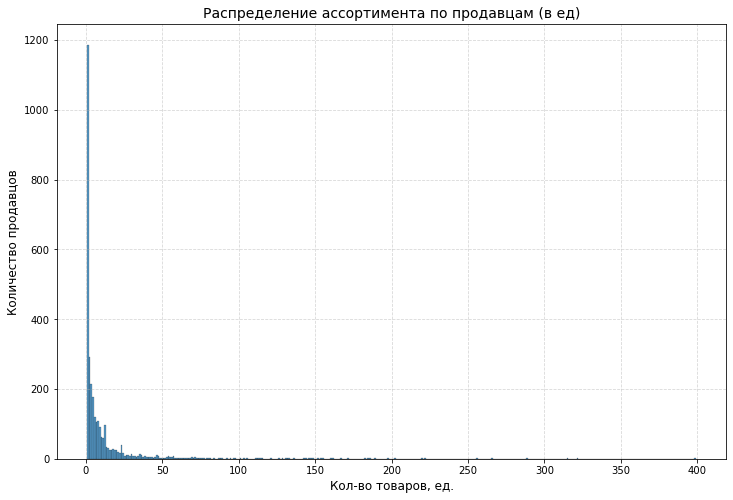

In [49]:
plt.figure(figsize=(12,8))

sns.histplot(data=sellers_products_orders.products_amount)

plt.title('Распределение ассортимента по продавцам (в ед)', fontsize=14)
plt.xlabel('Кол-во товаров, ед.', fontsize=12)
plt.ylabel('Количество продавцов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

In [50]:
quantiles_products_amount = sellers_products_orders.products_amount \
    .quantile([0.5, 0.9, 0.95, 0.99])
print(quantiles_products_amount)

0.50      4.00
0.90     25.00
0.95     44.30
0.99    127.12
Name: products_amount, dtype: float64


- Посмотрим на разные доли продавцов относительно широты ассортимента.

In [51]:
# Проверим, какую долю занимают продавцы с разным количеством товаров
product_sellers_proportion = sellers_products_orders.products_amount \
    .value_counts(normalize=True)

# Посмотрим какой процент продавцов имеют в ассортименте 1 товар
one_product_sellers = round(product_sellers_proportion.iloc[0] * 100, 2)
print(one_product_sellers)

# Проверим процент продавцов, у которых до 10 ед товара в ассортименте
up_to_ten = round(product_sellers_proportion.iloc[0:10].sum() * 100, 2)
print(up_to_ten)

24.1
76.09


- Посмотрим на распределение заказов по продавцам.
- Посмотрим на перцентили распредления заказов по продавцам.

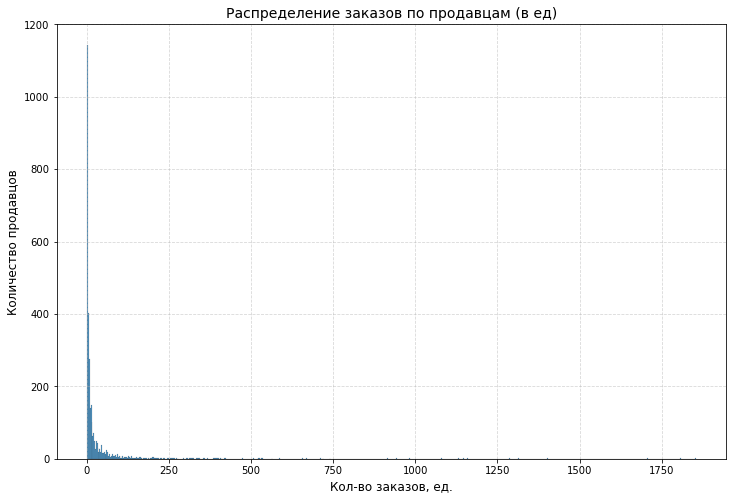

In [52]:
plt.figure(figsize=(12,8))

sns.histplot(data=sellers_products_orders.order_amount)

plt.title('Распределение заказов по продавцам (в ед)', fontsize=14)
plt.xlabel('Кол-во заказов, ед.', fontsize=12)
plt.ylabel('Количество продавцов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

In [53]:
quantiles_order_amount = sellers_products_orders.order_amount.quantile([0.5, 0.9, 0.95, 0.99])
print(quantiles_order_amount)

0.50      6.00
0.90     69.60
0.95    130.30
0.99    402.24
Name: order_amount, dtype: float64


- Проверим, есть ли корреляция между количеством заказов и количеством товаров у продавца.

In [54]:
# Подготовим переменные
products_var = sellers_products_orders.products_amount
orders_var = sellers_products_orders.order_amount

# Т.к. в данных присутствуют большие выбросы, используем коэффициент Спирмена
spearman_corr, spearman_p = st.spearmanr(products_var, orders_var)
print(spearman_corr, spearman_p)

0.9225556217997093 0.0


- Построим визуализацию распредления 2-х переменных (заказов и товаров).

Text(0, 0.5, 'Количество заказов')

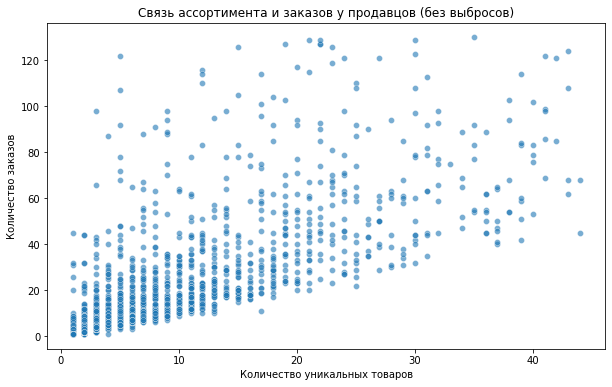

In [55]:
# Фильтруем данные для графика, чтобы убрать экстремальные выбросы
limit_orders = sellers_products_orders['order_amount'].quantile(0.95)
limit_products = sellers_products_orders['products_amount'].quantile(0.95)

limit_data = sellers_products_orders[
    (sellers_products_orders['order_amount'] <= limit_orders) & 
    (sellers_products_orders['products_amount'] <= limit_products)]

# Построим сам график
plt.figure(figsize=(10, 6))

sns.scatterplot(data=limit_data, x='products_amount', y='order_amount', alpha=0.6)

plt.title('Связь ассортимента и заказов у продавцов (без выбросов)')
plt.xlabel('Количество уникальных товаров')
plt.ylabel('Количество заказов')

- Проверим, есть ли значимая разница в удержании клиентов в зависимости от широты ассортимента продавцов.

In [56]:
# Разделим продавцов на сегменты по широте ассортимента
sellers_products_orders['assortment_segment'] = pd.cut(
    sellers_products_orders.products_amount,
    bins = [0, 1, 10, float('inf')],
    labels = ['Моно (1 товар)', 'Средний (2-10 товаров)', 
              'Широкий (11+ товаров)'])

In [57]:
# Подготовим датасет по клиентам:
# Добавим инфо по уникальному id клиента и id селлера, уберем неуспешные заказы.
# Добавим инфо с сегментами продавцов

orders_with_segments = order_data \
    .merge(order_items_data[['order_id', 'seller_id']],
          how='left',
          on='order_id') \
    .merge(customer_data[['customer_id', 'customer_unique_id']],
          how='left',
          on='customer_id') \
    .query('order_status not in ["canceled", "unavailable"]') \
    .merge(sellers_products_orders[['seller_id', 'assortment_segment']], 
           how='left', 
           on='seller_id')

In [58]:
# Найдем первый заказ для каждого клиента
first_order_segment = orders_with_segments \
    .sort_values('order_purchase_timestamp') \
    .groupby('customer_unique_id', as_index=False).first()

# Назначим флаг возвращаемости клиента
is_repeated_customers = orders_with_segments.groupby('customer_unique_id', as_index=False) \
    .agg({'order_id': 'nunique'}) \
    .rename(columns={'order_id': 'total_orders'}) \
    .assign(is_repeated = lambda x: x.total_orders > 1)

# Объединим датасеты
merged_data = first_order_segment \
    .merge(is_repeated_customers, how='left', on='customer_unique_id')

In [59]:
# Проверим возвращаемость клиентов относительно широты ассортимента продавца в первом заказе
merged_data.groupby('assortment_segment')['is_repeated'].mean() * 100

assortment_segment
Моно (1 товар)            2.726473
Средний (2-10 товаров)    2.458009
Широкий (11+ товаров)     3.174872
Name: is_repeated, dtype: float64

In [60]:
# Подготовим таблицу сопряженности:
contingency_table_4 = pd.crosstab(merged_data.assortment_segment, merged_data.is_repeated)

# Используем критерий Хи-квадрат для сравнения распределений
st.chi2_contingency(contingency_table_4)

Chi2ContingencyResult(statistic=24.746885384323136, pvalue=4.229432679756721e-06, dof=2, expected_freq=array([[1.10242901e+03, 3.45709864e+01],
       [1.65674622e+04, 5.19537770e+02],
       [7.44251088e+04, 2.33389124e+03]]))

In [61]:
# Фильтруем данные только для двух групп (моно и средний)
pair_1 = merged_data[merged_data['assortment_segment'].isin(['Моно (1 товар)', 'Средний (2-10 товаров)'])]

# Строим таблицу сопряженности
contingency_pair_1 = pd.crosstab(pair_1['assortment_segment'], pair_1['is_repeated'])

# Запускаем тест
chi2, p_val_pair_1, dof, expected = st.chi2_contingency(contingency_pair_1)
print(f"p-value (Моно vs Средний): {p_val_pair_1}")

p-value (Моно vs Средний): 0.6414636103008073


In [62]:
# Фильтруем данные только для двух групп (моно и широкий)
pair_2 = merged_data[merged_data['assortment_segment'].isin(['Моно (1 товар)', 'Широкий (11+ товаров)'])]

# Строим таблицу сопряженности 2х2
contingency_pair_2 = pd.crosstab(pair_2['assortment_segment'], pair_2['is_repeated'])

# Запускаем тест
chi2, p_val_pair_2, dof, expected = st.chi2_contingency(contingency_pair_2)
print(f"p-value (Моно vs Широкий): {p_val_pair_2}")

p-value (Моно vs Широкий): 0.44034333265520065


In [63]:
# Фильтруем данные только для двух групп (средний и широкий)
pair_3 = merged_data[merged_data['assortment_segment'].isin(['Средний (2-10 товаров)', 'Широкий (11+ товаров)'])]

# Строим таблицу сопряженности 2х2
contingency_pair_3 = pd.crosstab(pair_3['assortment_segment'], pair_3['is_repeated'])

# Запускаем тест
chi2, p_val_pair_3, dof, expected = st.chi2_contingency(contingency_pair_3)
print(f"p-value (Средний vs Широкий): {p_val_pair_3}")

p-value (Средний vs Широкий): 9.193217622834689e-07


In [64]:
# Применим поправку Холма на множественное сравнение
p_values = [0.6414636103008073, 0.44034333265520065, 9.193217622834689e-07]

rejected, pvals_corrected, alpha_sidak, alpha_bonf = multipletests(
    p_values, 
    alpha=0.05, 
    method='holm')
print("Значимые отличия, если True", rejected)

Значимые отличия, если True [False False  True]


**Выводы гипотеза 4:**

Что говорят данные:
1. 24% продавцов имеют в ассортименте всего 1 товар. 76% продавцов имеют в ассортименте до 10 товаров включительно.
2. Половина продавцов на платформе имеют не более 6 заказов. Только 1% продавцов получают больше 402 заказов.
3. Связь между широтой ассортимента и количеством заказов статистически значима, коэффициент корреляции близок к 1.
4. Уровень удержание клиентов статистически значимо выше в группе продавцов с широким ассортиментом (11+ товаров).

Выводы:
1. Огромное количество заказов держится на 1% селлеров, от которых зависим маркетплейс.
2. Большинство продавцов совершает небольшое количество продаж, при этом имеют маленький ассортимент.
3. Необходимо работать над разнообразием и устойчивостью селлеров, чтобы не зависеть от топ 1% продавцов, которые могут обрушить продажи. А также расширять ассортимент продавцов, чтобы увеличивать количество заказов и возвращаемость. Однако, это также не является основной причиной низкого PMF.

### Вывод по задаче 2: 
1. Product/market fit у продукта отсутствует. В ходе анализа график удержания не вышел на плато, что говорит о низком уровне соответствия продукта рынку.
2. Для продукта это признак "дырявого ведра" - пользователи уходят и не задерживаются нем. Масштабировать маркеплейс в таких условиях категорически нельзя - затраты на привлечение клиентов не будут окупаться их пожизненной ценностью.
3. Необходимо сфокусироваться на решении проблемы удержания пользователей, а для этого повысить конверсию в повторную покупку.
4. Проверенные факторы влияния времени доставки, стоимости доставки, неудачного первого заказа и широты ассортимента продавцов не являются основными причинами низкого PMF. Однако, обнаружены статистически значимые различия:
    - возвращаемость клиентов, которым задержали доставку, значимо ниже;
    - клиенты с более дорогой доставкой возвращается в повторную покупку значимо чаще, это может быть связано с отсутствием альтернатив в удаленных регионах;
    - клиенты неудачным первым заказом значимо чаще возвращаются в покупку, это может быть связано с тем, что они пытаются переоформить неудачный заказ;
    - связь между широтой ассортимента и количеством заказов статистически значима, коэффициент корреляции близок к 1;
    - уровень удержание клиентов статистически значимо выше в группе продавцов с широким ассортиментом (11+ товаров).
5. Маркетплейсу необходимо проверить:
    - наличие ассортимента повседневного спроса, возможно сейчас представлены только товары с низкой частотой покупки;
    - качество сервиса;
    - работу над возвращаемостью (пуши, напоминания, система лояльности, персональные рекомендации);
    - удобство самого приложения (клиентский путь до оформления покупки), может быть он не userfriendly.

---

### Задача 3.  Определить 5 основных метрик, на которых нужно сконцентрироваться, чтобы максимизировать прибыль компании.

**3.1. Первая метрика:** GMV (Gross Merchandise Value) - валовая стоимость товара, отражает рост объёма продаж маркетплейса.

1. Подготовим датасет: добавим к инфо по стоимости товара и доставки статус заказа и дату оформления заказа.
2. Оставим только успешные заказы.
3. Выделим для каждого заказа месяц его оформления.

In [65]:
orders = total_order_price \
    .merge(order_data[['order_id', 'order_status', 'order_purchase_timestamp']], 
                        how='left', 
                        on='order_id')

successful_orders = orders[~orders['order_status'] \
                           .isin(['unavailable', 'canceled'])].copy()

successful_orders['order_period_month'] = successful_orders.order_purchase_timestamp \
    .dt.to_period('M')

4. Посчитаем валовую стоимость товара по месяцам.
5. Для визуализации переведем столбец с типом period в строку.

In [66]:
gmv_by_month_data = successful_orders \
    .groupby('order_period_month', as_index=False) \
    .agg({'price': 'sum', 'freight_value': 'sum'}) \
    .assign(gmv_by_month = lambda x: x.price + x.freight_value)

gmv_by_month_data['order_period_month'] = gmv_by_month_data.order_period_month \
    .astype(str)

6. Построим линейный график, отражающий изменение GMV во времени.

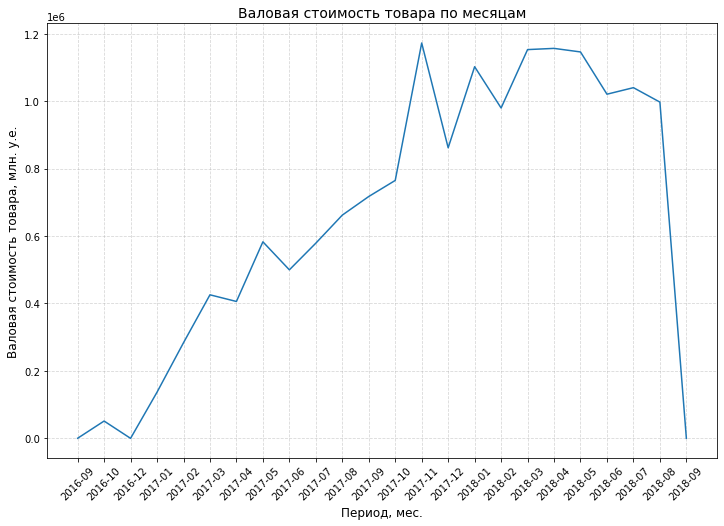

In [67]:
plt.figure(figsize=(12,8))

sns.lineplot(data=gmv_by_month_data, x='order_period_month', y='gmv_by_month')

plt.title('Валовая стоимость товара по месяцам', fontsize=14)
plt.xlabel('Период, мес.', fontsize=12)
plt.ylabel('Валовая стоимость товара, млн. у.е.', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.show()

7. Проверим причину низкого GMV в 2018-09.

In [68]:
# Данные за 2018-08
august_transactions = successful_orders[successful_orders.order_period_month == '2018-08'] \
    .groupby('order_id').agg({'order_status': 'count'}).shape

# Данные за 2018-09
september_transactions = successful_orders[successful_orders.order_period_month == '2018-09'] \
    .groupby('order_id').agg({'order_status': 'count'}).shape

print(f'Заказов в августе 2018: {august_transactions[0]}, заказов в сентябре 2018: {september_transactions[0]}')

Заказов в августе 2018: 6421, заказов в сентябре 2018: 1


**3.2. Вторая метрика:** MAB (Monthly Active Buyers) - вариация MAU, количество уникальных покупателей за месяц, показывает объем аудитории, которой продукт доставляет ценность.

1. Подготовим данные для визуализации.

In [69]:
# Возьмем из подготовленного ранее датасета только нужные колонки
mab_data = filtered_orders[['order_id', 'order_purchase_timestamp', 'customer_unique_id']] \
    .copy()

# Выделим для каждого заказа месяц его оформления
mab_data['order_period_month'] = mab_data.order_purchase_timestamp \
    .dt.to_period('M')

# Посчитаем количество уникальных покупателей за месяц
mab_by_month_data = mab_data \
    .groupby('order_period_month', as_index=False) \
    .agg({'customer_unique_id': 'nunique'}) \
    .rename(columns={'customer_unique_id': 'unique_customers_count'})

# Для визуализации переведем столбец с типом period в строку
mab_by_month_data['order_period_month'] = mab_by_month_data.order_period_month \
    .astype(str)

2. Построим линейный график, отражающий изменение MAB во времени.

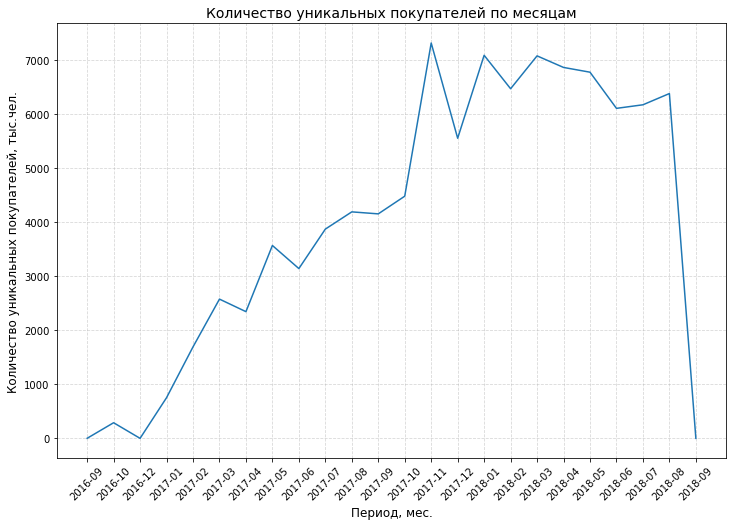

In [70]:
plt.figure(figsize=(12,8))

sns.lineplot(data=mab_by_month_data, x='order_period_month', y='unique_customers_count')

plt.title('Количество уникальных покупателей по месяцам', fontsize=14)
plt.xlabel('Период, мес.', fontsize=12)
plt.ylabel('Количество уникальных покупателей, тыс.чел.', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.show()

**3.3. Третья метрика:** доля клиентов,совершивших целевое действие в первую сессию, отражает заинтересованность новых клиентов в продукте.

Здесь не можем посчитать данную метрику, т.к. нет логов использования приложения клиентами до оформления заказа.

**3.4. Четвертая метрика:** доля повторных покупок клиентов, отражает вовлеченность клиента в продолжение использования продукта.

1. Подготовим данные для визуализации.

In [71]:
# Создадим копию подходящего датасета
repeated_order_data = mab_data.copy()

# Добавим колонку с датой первого заказа
repeated_order_data['first_order_date'] = mab_data.groupby('customer_unique_id').order_purchase_timestamp \
    .transform('min')

# Выявим для каждого заказа, является ли он повторным или нет
repeated_order_data['is_repeated_order'] = (repeated_order_data.order_purchase_timestamp > repeated_order_data.first_order_date) \
    .astype(int)

# Посчитаем долю повторных заказов по месяцам: 
repeated_order_percent = repeated_order_data \
    .groupby('order_period_month', as_index=False) \
    .agg({'is_repeated_order': 'mean'}) \
    .rename(columns={'is_repeated_order': 'repeated_orders_proportion'})

In [72]:
# Переведем столбец с типом period в строку, а долю в %
# Ууберем период 2018-09, чтобы не искажать график (1 заказ - повторный для клиента),

repeated_order_percent['order_period_month'] = repeated_order_percent.order_period_month \
    .astype(str)

repeated_order_percent['repeated_orders_proportion'] = repeated_order_percent['repeated_orders_proportion'] \
    .mul(100)

repeated_order_percent = repeated_order_percent[~(repeated_order_percent['order_period_month'] == '2018-09')]


2. Построим линейный график, отражающий процент повторных заказов во времени.

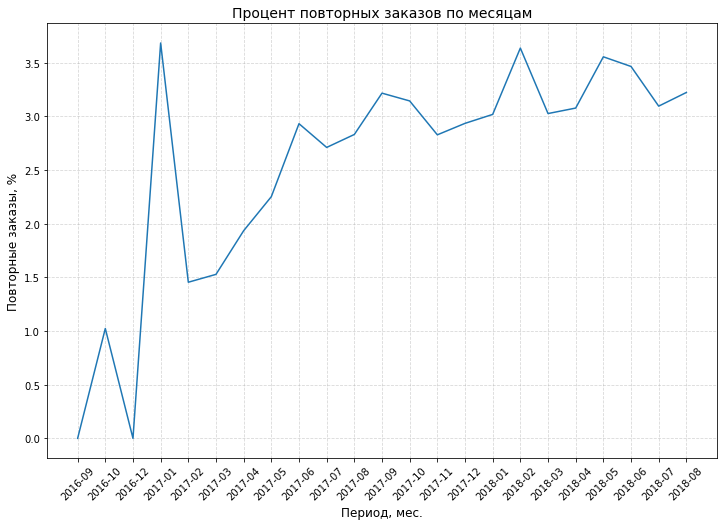

In [73]:
plt.figure(figsize=(12,8))

sns.lineplot(data=repeated_order_percent, x='order_period_month', y='repeated_orders_proportion')

plt.title('Процент повторных заказов по месяцам', fontsize=14)
plt.xlabel('Период, мес.', fontsize=12)
plt.ylabel('Повторные заказы, %', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.show()

**3.5. Пятая метрика:** ARPPU - average revenue per paying user, средняя выручка на платящего пользователя, отражает денежное выражение вовлеченности клиента.

1. Подготовим данные для визуализации.

In [74]:
# Смерджим уже имеющиеся данные по GMV и MAB
arppu_data = mab_by_month_data.merge(gmv_by_month_data[['order_period_month', 'gmv_by_month']], 
                        how='left', 
                        on='order_period_month')

# Сделаем расчет показателя ARPPU
arppu_data['arppu_by_month'] = arppu_data.gmv_by_month / arppu_data.unique_customers_count

2. Построим линейный график, отражающий изменение средней выручки на платящего пользователя во времени.

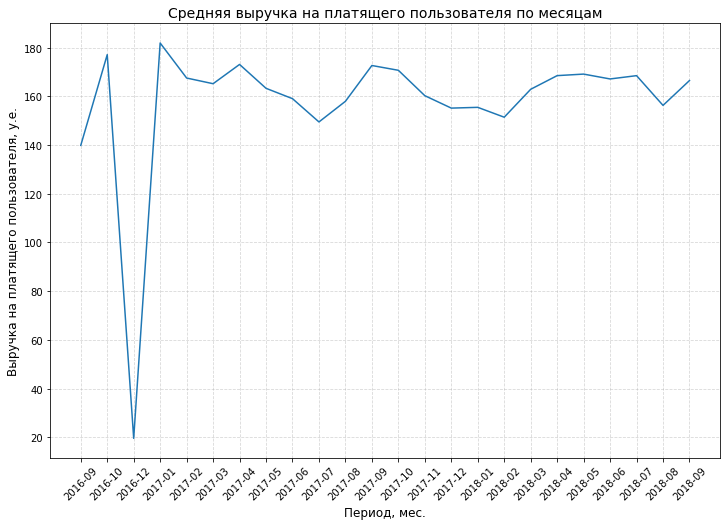

In [75]:
plt.figure(figsize=(12,8))

sns.lineplot(data=arppu_data, x='order_period_month', y='arppu_by_month')

plt.title('Средняя выручка на платящего пользователя по месяцам', fontsize=14)
plt.xlabel('Период, мес.', fontsize=12)
plt.ylabel('Выручка на платящего пользователя, у.е.', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.show()

3. Посмотрим на данные за период 2016-12, чтобы точнее понять причину провала.

In [76]:
check_2016_12 = mab_data[mab_data['order_period_month'] == '2016-12']
check_2016_12

,order_id,order_purchase_timestamp,customer_unique_id,order_period_month
39283,bd50a7fe9fd97ea4b7663031a319e150,2016-12-23 23:16:47,f7b981e8a280e455ac3cbe0d5d171bd1,2016-12


### Вывод по задаче 3: 
1. Первая метрика GMV - валовая стоимость товара. Данные за сентябрь 2018 неполные, т.к. включает только 1 заказ, против 6421 в августе. Скорее всего выгрузка была сделана в начале сентября.
2. Вторая метрика: MAB - количество уникальных покупателей за месяц. Графики GMV и MAB практически дублируют форму друг друга: если разложить GMV = MAB * средний чек * среднее число заказов на клиента, тогда идентичность графиков означает низкий retention (нет повторных покупок) и стабильный средний чек от месяца к месяцу.
3. Третья метрика: доля клиентов,совершивших целевое действие в первую сессию. Метрику можно посчитать при наличии логов использования приложения.
4. Четвертая метрика: доля повторных покупок клиентов. Данные за 2018-09 удалены для визуализации, чтобы избежать искажения графика.
5. Пятая метрика: ARPPU - средняя выручка на платящего пользователя. В период 2016-12 был совершен только 1 заказ: слишком мало данных на старте продукта.

---

### Задача 4.  Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Для расчета Impact взяты данные с 2017-06.
Конверсия в повторный заказ равна 0.0037

In [77]:
repeated_order_cr = 0.0037

1. Impact гипотезы 1: Метрика - количество заказов. Увеличится на количество заказов со статусом canceled.

In [78]:
# Посчитаем количество заказов со статусом canceled и фильтром по дате

canceled_orders = order_data \
    .query('order_purchase_timestamp >= "2017-06-01" & order_status == "canceled"')

impact_hypothesis_1 = canceled_orders.shape[0]
print(f'Impact гипотезы 1: {impact_hypothesis_1} новых заказов')
print(f'Оценка в баллах: 4')

Impact гипотезы 1: 499 новых заказов
Оценка в баллах: 4


2. Impact гипотезы 2: Метрика - количество заказов. Увеличится на количество повторных заказов от клиентов, которые получили заказ с задержкой.

In [79]:
# Возьмем подходящий датасет по доставленным заказам,
# отфильтруем заказы с задержкой и по дате,
# посчитаем уникальных клиентов, получивших заказ с опозданием

customers_with_delayed_orders = delivered_orders.query('order_purchase_timestamp >= "2017-06-01" & is_delayed == "delayed"') \
    .customer_unique_id.nunique()

# Посчитаем количество повторных заказов от полученной группы клиентов
impact_hypothesis_2 = round((customers_with_delayed_orders * repeated_order_cr), 0)
print(f'Impact гипотезы 2: {impact_hypothesis_2} новых заказов')
print(f'Оценка в баллах: 1')

Impact гипотезы 2: 27.0 новых заказов
Оценка в баллах: 1


3. Impact гипотезы 3: Метрика - количество заказов. Увеличится на количество повторных заказов от клиентов с 1 заказом.

In [80]:
# Используем подходящий датасет, отфильтруем по дате,
# посчитаем уникальных клиентов, которые совершили только 1 заказ

one_order_customers = filtered_orders \
    .query('order_purchase_timestamp >= "2017-06-01"') \
    .groupby('customer_unique_id', as_index=False) \
    .agg({'order_id': 'nunique'}) \
    .query('order_id == 1') \
    .shape[0]

# Посчитаем количество повторных заказов от полученной группы клиентов
impact_hypothesis_3 = round((one_order_customers * repeated_order_cr), 0)
print(f'Impact гипотезы 3: {impact_hypothesis_3} новых заказов')
print(f'Оценка в баллах: 3')

Impact гипотезы 3: 303.0 новых заказов
Оценка в баллах: 3


4. Рассчитаем баллы для каждой гипотезы по ICE:

In [81]:
# Создадим списки со значениями по Impact, Confidence, Ease в баллах
list_of_impact     = [4, 1, 3]
list_of_confidence = [8, 10, 5]
list_of_ease       = [6, 4, 9]

# Рассчитаем финальную оценку гипотез по фреймворку ICE
result_ice = [x*y*z for x, y, z in zip(list_of_impact, list_of_confidence, list_of_ease)]
print(f"""Финальная оценка
      Гипотеза 1: {result_ice[0]}
      Гипотеза 2: {result_ice[1]}
      Гипотеза 3: {result_ice[2]}
      
Приоритетная гипотеза со значением: {max(result_ice)}""")

Финальная оценка
      Гипотеза 1: 192
      Гипотеза 2: 40
      Гипотеза 3: 135
      
Приоритетная гипотеза со значением: 192


In [82]:
total_order_price['order_price'] = total_order_price.price + total_order_price.freight_value
total_order_price.order_price.median()

105.28

### Вывод по задаче 4: 
1. Приоритетная гипотеза для реализации - гипотеза 1 с финальной оценкой 192 по фреймворку ICE: 

"Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен".

---

### Задача 5.  Сформулировать нужные метрики, на которые повлияет выбранная гипотеза.

**Целевая метрика**:
Процент успешно доставленных заказов

Чувствительность: форма этой метрики в долях меньше подвержена влиянию от увеличения/ уменьшения привлеченных клиентов, а также в состоянии задетектировать стат значимое различие.

Достоверность: мы без труда можем посчитать эту метрику на полученных данных:  кол-во доставленных заказов / кол-во оформленных заказов * 100%.

Интерпретируемость - метрика отражает результат, к которому мы хотим прийти, а именно снижение доли отмен и увеличение доли успешно доставленных заказов.

**Прокси-метрика**: Процент отмененных заказов от числа подтвержденных

Чувствительность: форма этой метрики в долях меньше подвержена влиянию от увеличения/ уменьшения привлеченных клиентов, а также в состоянии задетектировать стат значимое изменение.

Достоверность: мы можем посчитать эту метрику на полученных данных: кол-во отмененных заказов / кол-во подтвержденных заказов * 100%

Интерпретируемость - показывает, стали ли оплаченные заказы отменяться реже благодаря внедренным изменениям.

**Барьерная метрика**: Конверсия в заказ

Чувствительность: форма этой метрики в долях меньше подвержена влиянию от увеличения/ уменьшения привлеченных клиентов.

Достоверность: мы можем посчитать эту метрику на полученных данных: кол-во оформленных заказов / кол-во посетителей * 100%

Интерпретируемость - если метрика будет падать, это покажет, что наши изменения негативно повлияли на сам факт совершения заказа, а значит бизнес будет терять в выручке.

### Вывод по задаче 5: 
1. Для проведения A/B тестирования были выбраны следующие метрики:
    - Целевая метрика: Процент успешно доставленных заказов;
    - Прокси-метрика: Процент отмененных заказов от числа подтвержденных;
    - Барьерная метрика: Конверсия в заказ.
2. Все эти метрики обладают чувствительностью и их легко рассчитать на имеющихся данных.
3. Целевая метрика отражает результат, который мы ожидаем от внедрения улучшения. Прокси-метрика даст понять, что изменение действительно сработало, т.к. процент отмененных заказов будет падать еще до момента доставки. Барьерная метрика станет сигналом, что "ничего не сломалось" на других этапах.

---

### Задача 6.  Сформулировать выводы о проделанной работе и подготовить содержательный отчет.

Отчет по анализу работы маркетплейса:

**Проблема продукта:**

- Было принято решение провести анализ работы маркетплейса, т.к. его выручка стоит на одном месте уже несколько месяцев.

- По результатам проведенного анализа стало понятно, что проблема лежит на уровне удержания клиентов в продукте.
---
**Результаты анализа и выводы:**

- Был проведен месячный когортный анализ, который показал, что удержание клиентов находится на уровне менее 1%. 
- На каждые 10000 клиентов, совершивших первый заказ, только около 37 человек возвращаются за повторным заказом в течение следующих 30 дней.
- Это означает, что продукт пока не закрывает задачу клиента, не несет для него ценности.
---
- Основным показателем соответствия продукта рынку (той самой ценности и закрытия задач клиента) является как раз показатель удержания.
- График удержания не вышел на необходимое плато, что говорит о низком уровне соответствия продукта рынку.
- Для продукта это признак "дырявого ведра" - пользователи уходят и не задерживаются в нем.
- Отдельно проанализировали показатели локального удержания в регионе SP, с наилучшими условиями доставки, но даже там уровень удержания крайне низкий.
---
- Проверены несколько гипотез проблемы удержания клиентов: 
    - влияние времени доставки (своевременность или задержка);
    - влияние стоимости доставки (высокая/низкая доля стоимости доставка от цены заказа);
    - влияние неудачного первого заказа (отмена или недоступность товара);
    - влияние широты ассортимента у продавца.


- Время доставки: по медиане 10 дней на доставку, что довольно долго на современном рынке, 8% задержанных заказов;
- Стоимость доставки: по медиане 22% стоит доставка от суммы заказа, может доходить почти до половины от стоимости заказа в удаленных регионах, что может быть стоп-фактором при оформлении заказа;
- Неудачный первый заказ: 1,24% неудачных заказов (отменены или out-of-stock);
- Широта ассортимента: 24% продавцов имеют в ассортименте всего 1 товар, 76% - до 10 товаров включительно.Только 1% продавцов получают больше 402 заказов, что может потенциально обрушить продажи в случае их ухода.


- Указанные факторы не являются основными причинами низкого удержания клиентов. Даже при идеальных условиях (например, своевременная/дешевая/успешная доставка/широкий ассортимент продавца) процент удержания крайне низкий. Однако, стоит отметить, что есть статистически значимые различия в проверенных группах:
    - возвращаемость клиентов, которым задержали доставку, значимо ниже;
    - клиенты с более дорогой доставкой возвращается в повторную покупку значимо чаще, это может быть связано с отсутствием альтернатив в удаленных регионах;
    - клиенты неудачным первым заказом значимо чаще возвращаются в покупку, это может быть связано с тем, что они пытаются переоформить неудачный заказ;
    - связь между широтой ассортимента и количеством заказов статистически значима, коэффициент корреляции близок к 1;
    - уровень удержание клиентов значимо выше в группе продавцов с широким ассортиментом (11+ товаров).
---
- Выявлены отдельные ветви дерева метрик, на которых нужно сконцентрироваться для увеличения прибыли компании.
    - GMV - валовая стоимость товара
        - MAB - количество уникальных покупателей за месяц
            - доля клиентов, совершивших целевое действие в первую сессию
            - доля повторных покупок клиентов
        - ARPPU - средняя выручка на платящего пользователя
---    
- В ходе работы была выбрана приоритетная гипотеза решения с финальной оценкой 192 балла по фреймворку ICE:

"Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен".    

---
- На основании выбранной гипотезы решения определила основные метрики для проведения A/B теста:
    
    - Целевая метрика: Процент успешно доставленных заказов;
    - Прокси-метрика: Процент отмененных заказов от числа подтвержденных;
    - Барьерная метрика: Конверсия в покупку.
    
    
- Все эти метрики обладают чувствительностью и их легко рассчитать на имеющихся данных.
- Целевая метрика отражает результат, который мы ожидаем от внедрения улучшения.
- Прокси-метрика даст понять, что изменение действительно сработало, т.к. процент отмененных заказов будет падать еще до момента доставки.
- Барьерная метрика станет сигналом, что "ничего не сломалось" на других этапах.

---
**Рекомендации:**

- Масштабировать маркеплейс в таких условиях категорически нельзя. Затраты на привлечение клиентов не будут окупаться их пожизненной ценностью.


- Необходимо сфокусироваться на решении проблемы удержания пользователей, а для этого повысить конверсию в повторную покупку.


- Маркетплейсу необходимо проверить:
    - наличие ассортимента повседневного спроса, возможно сейчас представлены только товары с низкой частотой покупки;
    - качество сервиса;
    - работу над возвращаемостью (пуши, напоминания, система лояльности, персональные рекомендации);
    - удобство самого приложения (клиентский путь до оформления покупки), может быть он не userfriendly.


- Проблемы времени доставки, стоимости доставки, неудачного первого заказа и широты ассортимента требуют доработки после решения основной проблемы.


- Стоит сконцентрироваться на количестве уникальных покупателей за месяц:
    - с одной стороны наращивать долю повторных покупок;
    - с другой удерживать долю клиентов, совершивших целевое действие в 1 визит.


- Провести A/B тестирование гипотезы и внедрить улучшения, если в тестовой группе будут выявлены статистически значимые положительные различия.